# 03 Exploratory Data Analysis (EDA)
Visualize patterns, distributions, and relationships in the customer feedback data.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Load cleaned data
DATA_PATH = '../data/cleaned_reviews.csv'
df = pd.read_csv(DATA_PATH, engine="python")
print(f'Loaded {len(df)} reviews')
df.head()

Loaded 20370 reviews


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,reviewText_clean,Rating_Num,sentiment
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024",registered website tried order laptop entered ...,1.0,Negative
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024",multiple orders one turned driver phone door n...,1.0,Negative
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024",informed reprobates would going visit sick rel...,1.0,Negative
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024",bought amazon problems happy service price ama...,1.0,Negative
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024",could give lower rate would cancelled amazon p...,1.0,Negative


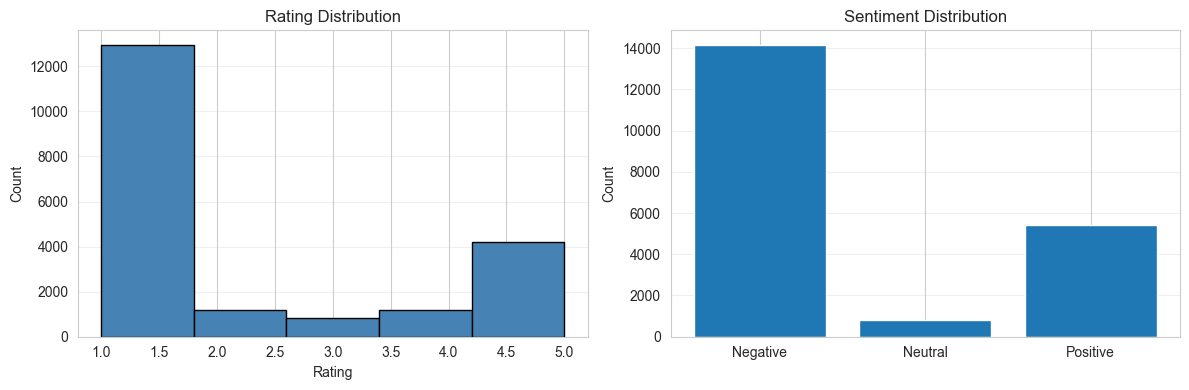


Rating breakdown:
Rating_Num
1.0    12949
2.0     1201
3.0      822
4.0     1184
5.0     4214
Name: count, dtype: int64


In [7]:
# 1. Rating distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['Rating_Num'], bins=5, edgecolor='black', color='steelblue')
ax[0].set_xlabel('Rating')
ax[0].set_ylabel('Count')
ax[0].set_title('Rating Distribution')
ax[0].grid(axis='y', alpha=0.3)

sentiment_counts = df['sentiment'].value_counts().reindex(
    ['Negative', 'Neutral', 'Positive']
)

ax[1].bar(
    sentiment_counts.index,
    sentiment_counts.values
)

ax[1].set_ylabel('Count')
ax[1].set_title('Sentiment Distribution')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nRating breakdown:')
print(df['Rating_Num'].value_counts().sort_index())

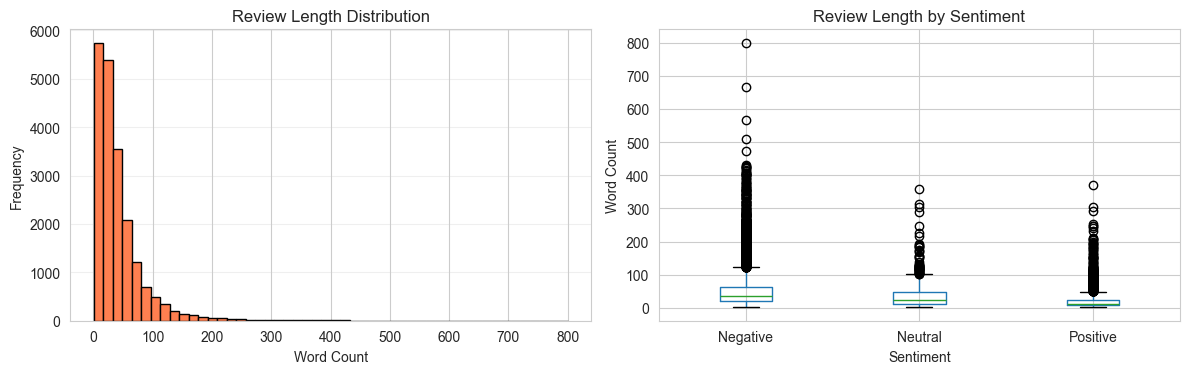


Text length stats:
count    20370.000000
mean        41.793471
std         44.178858
min          1.000000
25%         15.000000
50%         29.000000
75%         52.000000
max        800.000000
Name: text_length, dtype: float64


In [8]:
# 2. Text length analysis
df['text_length'] = df['reviewText_clean'].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['text_length'], bins=50, edgecolor='black', color='coral')
ax[0].set_xlabel('Word Count')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Review Length Distribution')
ax[0].grid(axis='y', alpha=0.3)

df.boxplot(column='text_length', by='sentiment', ax=ax[1])
ax[1].set_xlabel('Sentiment')
ax[1].set_ylabel('Word Count')
ax[1].set_title('Review Length by Sentiment')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'\nText length stats:')
print(df['text_length'].describe())

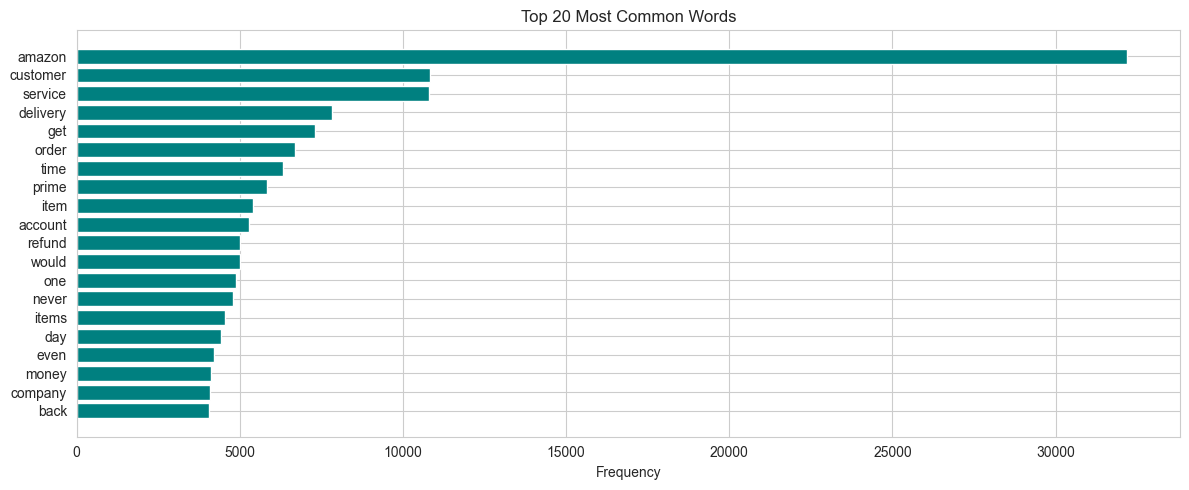


Unique words: 26039
Top 20 words: {'amazon': 32201, 'customer': 10826, 'service': 10794, 'delivery': 7838, 'get': 7317, 'order': 6687, 'time': 6321, 'prime': 5833, 'item': 5411, 'account': 5287, 'refund': 5013, 'would': 4997, 'one': 4890, 'never': 4787, 'items': 4544, 'day': 4429, 'even': 4210, 'money': 4101, 'company': 4084, 'back': 4059}


In [9]:
# 3. Top words
from collections import Counter

all_words = ' '.join(df['reviewText_clean']).split()
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

words, counts = zip(*top_20)
plt.figure(figsize=(12, 5))
plt.barh(words, counts, color='teal')
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\nUnique words: {len(word_freq)}')
print('Top 20 words:', dict(top_20))

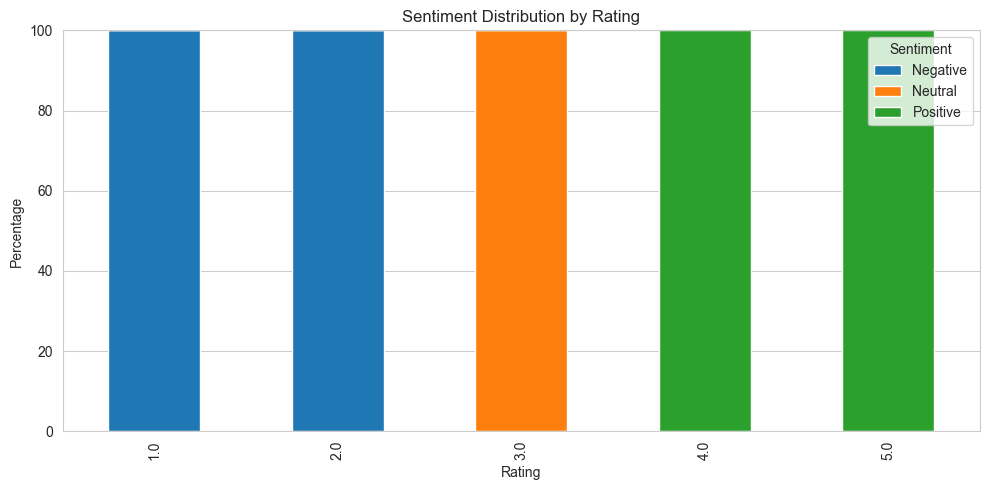

In [11]:
sentiment_by_rating = pd.crosstab(
    df['Rating_Num'],
    df['sentiment'],
    normalize='index'
) * 100

sentiment_by_rating.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel('Rating')
plt.ylabel('Percentage')
plt.title('Sentiment Distribution by Rating')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()